In [2]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Conectar ao banco
conn = psycopg2.connect(
    dbname="mimiciv",
    user="desafio_mimic",
    password="desafio_mimic",
    host="localhost",
    port="5432"
)


📊 Resumo de Mortalidade com Classificação Técnica:
   obito_uti  obito_hosp  obito_1ano  sobreviventes  obitos_totais  \
0       7710        1996        9639          46021          19345   

   total_pacientes  
0            65366  


/tmp/ipykernel_25474/751421308.py:57: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_resultado = pd.read_sql(query_resultado, conn)
/tmp/ipykernel_25474/751421308.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
/tmp/ipykernel_25474/751421308.py:89: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  barplot = sns.barplot(


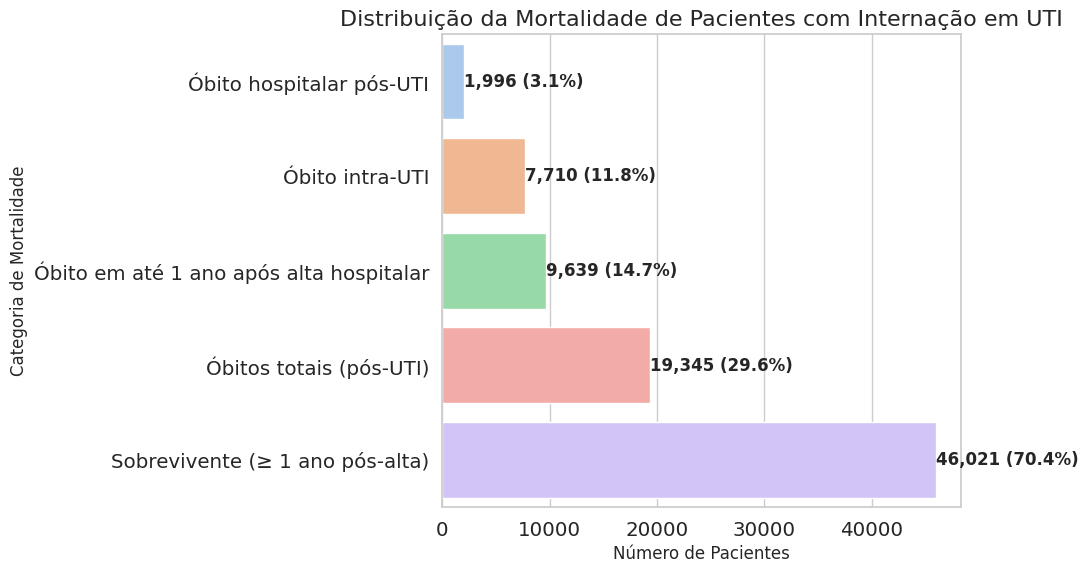

In [3]:
cursor = conn.cursor()

# SQL com mortalidade exclusiva baseada na última UTI, salvando como pacientes_mortos
sql_script = """
-- Última internação na UTI por paciente
CREATE TEMP TABLE ultima_uti AS
SELECT *
FROM (
    SELECT 
        i.subject_id,
        i.hadm_id,
        i.stay_id,
        i.intime,
        i.outtime,
        p.dod,
        a.admittime,
        a.dischtime,
        a.hospital_expire_flag,
        ROW_NUMBER() OVER (PARTITION BY i.subject_id ORDER BY i.outtime DESC) AS rn
    FROM mimiciv_icu.icustays i
    JOIN mimiciv_hosp.admissions a ON i.hadm_id = a.hadm_id
    JOIN mimiciv_hosp.patients p ON i.subject_id = p.subject_id
) t
WHERE rn = 1;

-- Tabela final com classificação exclusiva e nome técnico
CREATE TEMP TABLE pacientes_mortos AS
SELECT
  subject_id,
  stay_id,
  CASE
    WHEN dod IS NOT NULL AND dod <= outtime THEN 'Óbito intra-UTI'
    WHEN dod IS NOT NULL AND dod > outtime AND dod <= dischtime THEN 'Óbito hospitalar pós-UTI'
    WHEN dod IS NOT NULL AND dod > dischtime AND dod <= dischtime + INTERVAL '1 year' THEN 'Óbito em até 1 ano após alta hospitalar'
    ELSE 'Sobrevivente (≥ 1 ano pós-alta)'
  END AS categoria
FROM ultima_uti;
"""

# Executar SQL
cursor.execute("ROLLBACK")
cursor.execute(sql_script)
conn.commit()

# Consulta dos dados agregados
query_resultado = """
SELECT
  COUNT(*) FILTER (WHERE categoria = 'Óbito intra-UTI') AS obito_uti,
  COUNT(*) FILTER (WHERE categoria = 'Óbito hospitalar pós-UTI') AS obito_hosp,
  COUNT(*) FILTER (WHERE categoria = 'Óbito em até 1 ano após alta hospitalar') AS obito_1ano,
  COUNT(*) FILTER (WHERE categoria = 'Sobrevivente (≥ 1 ano pós-alta)') AS sobreviventes,
  COUNT(*) FILTER (WHERE categoria != 'Sobrevivente (≥ 1 ano pós-alta)') AS obitos_totais,
  COUNT(*) AS total_pacientes
FROM pacientes_mortos;
"""

df_resultado = pd.read_sql(query_resultado, conn)

# Exibir os dados
print("\n📊 Resumo de Mortalidade com Classificação Técnica:")
print(df_resultado)

# Montar dados para o gráfico
dados = {
    'Categoria de Mortalidade': [
        'Óbito intra-UTI',
        'Óbito hospitalar pós-UTI',
        'Óbito em até 1 ano após alta hospitalar',
        'Óbitos totais (pós-UTI)',
        'Sobrevivente (≥ 1 ano pós-alta)'
    ],
    'Quantidade': [
        df_resultado['obito_uti'][0],
        df_resultado['obito_hosp'][0],
        df_resultado['obito_1ano'][0],
        df_resultado['obitos_totais'][0],
        df_resultado['sobreviventes'][0]
    ]
}

df_plot = pd.DataFrame(dados)
df_plot['Porcentagem (%)'] = df_plot['Quantidade'] / df_resultado['total_pacientes'][0] * 100

# Estética
sns.set(style="whitegrid", font_scale=1.3)
cores = sns.color_palette("pastel")

plt.figure(figsize=(11, 6))
barplot = sns.barplot(
    data=df_plot.sort_values('Quantidade', ascending=True), 
    x='Quantidade', y='Categoria de Mortalidade', palette=cores
)

# Texto nas barras
for i, (qtd, pct) in enumerate(zip(df_plot.sort_values('Quantidade', ascending=True)['Quantidade'],
                                   df_plot.sort_values('Quantidade', ascending=True)['Porcentagem (%)'])):
    barplot.text(qtd + 20, i, f'{qtd:,} ({pct:.1f}%)', va='center', fontsize=12, fontweight='bold')

plt.title("Distribuição da Mortalidade de Pacientes com Internação em UTI", fontsize=16)
plt.xlabel("Número de Pacientes", fontsize=12)
plt.ylabel("Categoria de Mortalidade", fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
# Execute the SQL query to list tables with names containing 'labevents'
query_tables = """
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_name ILIKE '%ingredientevents%';
"""
cursor.execute(query_tables)



# Fetch and display the results
tables = cursor.fetchall()
for table_schema, table_name in tables:
	print(f"Schema: {table_schema}, Table: {table_name}")


Schema: mimiciv_icu, Table: ingredientevents


In [5]:
# Consulta simples para verificar a existência de dados de lactato (itemid 220948) na tabela chartevents
query_teste_lactato = """
SELECT * 
FROM mimiciv_icu.inputevents  -- Substitua pelo esquema correto, se necessário
WHERE itemid = 220948
LIMIT 10;
"""

# Executar a consulta
try:
    cursor.execute(query_teste_lactato)
    resultados = cursor.fetchall()

    # Exibir os resultados
    if resultados:
        print("📋 Resultados da consulta (primeiros 10 registros):")
        for row in resultados:
            print(row)
    else:
        print("⚠️ Nenhum dado encontrado para o itemid 220948 na tabela ingredientevents.")
except Exception as e:
    print(f"❌ Erro ao executar a consulta: {e}")

⚠️ Nenhum dado encontrado para o itemid 220948 na tabela ingredientevents.


/tmp/ipykernel_25474/3411308248.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_uso_lactato = pd.read_sql(sql_query_uso_lactato, conn)



📊 Quantidade de Pacientes com e sem Lactato (Lab) e suas Mortalidades:
         grupo  total_pacientes  total_mortes  taxa_mortalidade
0  Com Lactato            44391         15114         34.047442
1  Sem Lactato            20975          4231         20.171633


/tmp/ipykernel_25474/3411308248.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_uso_lactato, x="grupo", y="taxa_mortalidade", palette="magma", edgecolor='black')


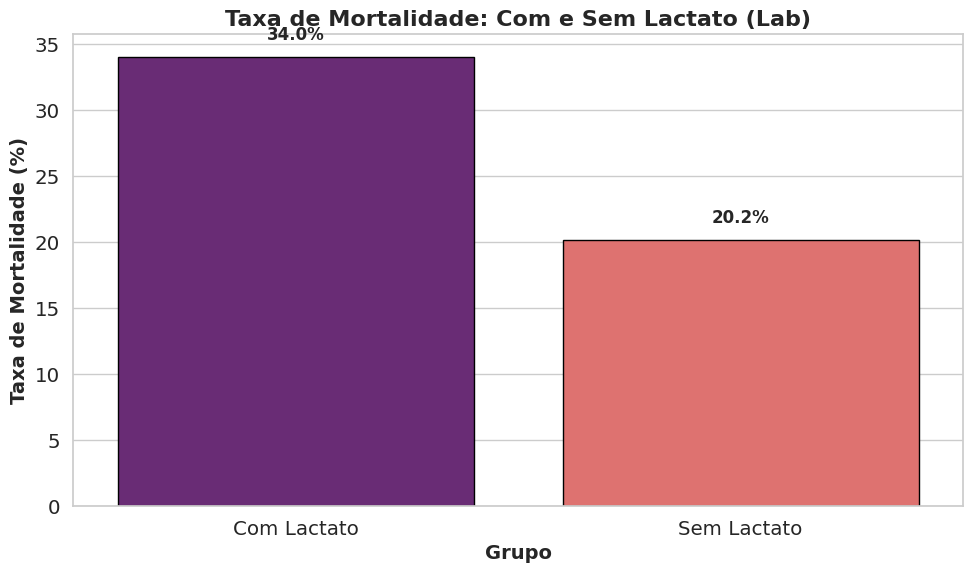

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Corrigir transação abortada
cursor.execute("ROLLBACK")

sql_query_uso_lactato = """
-- Lactato por subject_id (paciente), não por stay_id
WITH lactato_labevents AS (
    SELECT DISTINCT le.subject_id, le.hadm_id, 1 AS tem_lactato
    FROM mimiciv_hosp.labevents le
    WHERE le.itemid = 50813
      AND le.valuenum IS NOT NULL
),
pacientes_com_lactato AS (
    SELECT DISTINCT pm.stay_id
    FROM pacientes_mortos pm
    JOIN mimiciv_icu.icustays icu 
        ON pm.stay_id = icu.stay_id
    JOIN lactato_labevents lact 
        ON icu.subject_id = lact.subject_id AND icu.hadm_id = lact.hadm_id
)
SELECT 
    CASE 
        WHEN pm.stay_id IN (SELECT stay_id FROM pacientes_com_lactato) THEN 'Com Lactato'
        ELSE 'Sem Lactato'
    END AS grupo,
    COUNT(*) AS total_pacientes,
    SUM(CASE WHEN pm.categoria != 'Sobrevivente (≥ 1 ano pós-alta)' THEN 1 ELSE 0 END) AS total_mortes
FROM pacientes_mortos pm
GROUP BY grupo;

"""

# Carregar os resultados em um DataFrame
df_uso_lactato = pd.read_sql(sql_query_uso_lactato, conn)

# Calcular a taxa de mortalidade
df_uso_lactato['taxa_mortalidade'] = (df_uso_lactato['total_mortes'] / df_uso_lactato['total_pacientes']) * 100

# Exibir os resultados
print("\n📊 Quantidade de Pacientes com e sem Lactato (Lab) e suas Mortalidades:")
print(df_uso_lactato)

# Visualização
plt.figure(figsize=(10, 6))
sns.barplot(data=df_uso_lactato, x="grupo", y="taxa_mortalidade", palette="magma", edgecolor='black')

plt.title("Taxa de Mortalidade: Com e Sem Lactato (Lab)", fontsize=16, fontweight='bold')
plt.xlabel("Grupo", fontsize=14, fontweight='bold')
plt.ylabel("Taxa de Mortalidade (%)", fontsize=14, fontweight='bold')

for i, taxa in enumerate(df_uso_lactato['taxa_mortalidade']):
    plt.text(i, taxa + 1, f"{taxa:.1f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()



/tmp/ipykernel_25474/2565661606.py:66: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lactato_valores = pd.read_sql(sql_query_lactato_valores, conn)



📊 Mortalidade por Nível de Lactato:
           grupo_lactato  total_pacientes  total_mortes  taxa_mortalidade
0  Lactato Elevado (≥ 2)            16149          7411         45.891386
1   Lactato Normal (< 2)            28242          7703         27.274981
2   Sem Exame de Lactato            20975          4231         20.171633


/tmp/ipykernel_25474/2565661606.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_lactato_valores, x="grupo_lactato", y="taxa_mortalidade", palette="flare", edgecolor='black')


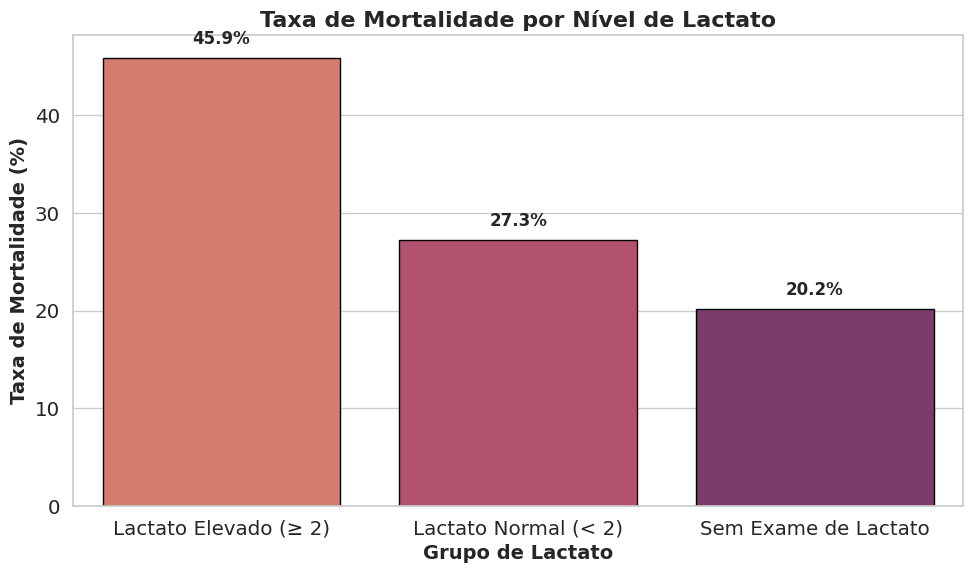

In [19]:
# Corrigir transação abortada
cursor.execute("ROLLBACK")

sql_query_lactato_valores = """

WITH lactato_classificacao AS (
    SELECT DISTINCT
        le.subject_id,
        le.hadm_id,
        CASE
            WHEN le.valuenum >= 2 THEN 'Lactato Elevado (≥ 2)'
            WHEN le.valuenum < 2 THEN 'Lactato Normal (< 2)'
            ELSE 'Desconhecido'
        END AS grupo_lactato
    FROM mimiciv_hosp.labevents le
    WHERE le.itemid = 50813
      AND le.valuenum IS NOT NULL
),
primeiro_lactato AS (
    -- Se houver múltiplos registros por paciente, pegar o primeiro
    SELECT subject_id, hadm_id, grupo_lactato
    FROM (
        SELECT
            le.subject_id,
            le.hadm_id,
            CASE
                WHEN le.valuenum >= 2 THEN 'Lactato Elevado (≥ 2)'
                WHEN le.valuenum < 2 THEN 'Lactato Normal (< 2)'
            END AS grupo_lactato,
            ROW_NUMBER() OVER (PARTITION BY le.subject_id, le.hadm_id ORDER BY le.charttime) as rn
        FROM mimiciv_hosp.labevents le
        WHERE le.itemid = 50813
          AND le.valuenum IS NOT NULL
    ) sub
    WHERE rn = 1
),
pacientes_com_lactato AS (
    SELECT icu.stay_id, pl.grupo_lactato
    FROM primeiro_lactato pl
    JOIN mimiciv_icu.icustays icu 
        ON icu.subject_id = pl.subject_id AND icu.hadm_id = pl.hadm_id
),
pacientes_rotulados AS (
    SELECT
        pm.stay_id,
        COALESCE(pcl.grupo_lactato, 'Sem Exame de Lactato') AS grupo_lactato,
        CASE 
            WHEN pm.categoria != 'Sobrevivente (≥ 1 ano pós-alta)' THEN 1 ELSE 0
        END AS morreu
    FROM pacientes_mortos pm
    LEFT JOIN pacientes_com_lactato pcl
        ON pm.stay_id = pcl.stay_id
)
SELECT 
    grupo_lactato,
    COUNT(*) AS total_pacientes,
    SUM(morreu) AS total_mortes
FROM pacientes_rotulados
GROUP BY grupo_lactato;
"""

# Consulta SQL (substitua como string no Python)
#sql_query_lactato_valores = """ ... """

# Executar e carregar no DataFrame
df_lactato_valores = pd.read_sql(sql_query_lactato_valores, conn)

# Calcular taxa de mortalidade
df_lactato_valores['taxa_mortalidade'] = (
    df_lactato_valores['total_mortes'] / df_lactato_valores['total_pacientes'] * 100
)

# Exibir os resultados
print("\n📊 Mortalidade por Nível de Lactato:")
print(df_lactato_valores)

# Gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=df_lactato_valores, x="grupo_lactato", y="taxa_mortalidade", palette="flare", edgecolor='black')

plt.title("Taxa de Mortalidade por Nível de Lactato", fontsize=16, fontweight='bold')
plt.xlabel("Grupo de Lactato", fontsize=14, fontweight='bold')
plt.ylabel("Taxa de Mortalidade (%)", fontsize=14, fontweight='bold')

for i, taxa in enumerate(df_lactato_valores['taxa_mortalidade']):
    plt.text(i, taxa + 1, f"{taxa:.1f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()



In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#consulta simples para verificar a existência de dados de MAP (itemid 227023) na tabela chartevents
query_teste_map = """
SELECT *
FROM mimiciv_icu.chartevents  -- Substitua pelo esquema correto, se necessário
WHERE itemid = 220052
LIMIT 10;
"""
# Executar a consulta
try:
    cursor.execute(query_teste_map)
    resultados = cursor.fetchall()

    # Exibir os resultados
    if resultados:
        print("📋 Resultados da consulta (primeiros 10 registros):")
        for row in resultados:
            print(row)
    else:
        print("⚠️ Nenhum dado encontrado para o itemid 227023 na tabela chartevents.")
except Exception as e:
    print(f"❌ Erro ao executar a consulta: {e}")

📋 Resultados da consulta (primeiros 10 registros):
(10003400, 20214994, 32128372, 88582, datetime.datetime(2137, 2, 26, 20, 3), datetime.datetime(2137, 2, 27, 3, 4), 220052, '80', 80.0, 'mmHg', 0)
(10003400, 20214994, 32128372, 88582, datetime.datetime(2137, 2, 26, 21, 3), datetime.datetime(2137, 2, 27, 3, 4), 220052, '82', 82.0, 'mmHg', 0)
(10003400, 20214994, 32128372, 88582, datetime.datetime(2137, 2, 26, 22, 0), datetime.datetime(2137, 2, 26, 22, 37), 220052, '79', 79.0, 'mmHg', 0)
(10003400, 20214994, 32128372, 88582, datetime.datetime(2137, 2, 26, 22, 3), datetime.datetime(2137, 2, 27, 3, 4), 220052, '81', 81.0, 'mmHg', 0)
(10003400, 20214994, 32128372, 88582, datetime.datetime(2137, 2, 26, 23, 0), datetime.datetime(2137, 2, 26, 23, 29), 220052, '77', 77.0, 'mmHg', 0)
(10003400, 20214994, 32128372, 88582, datetime.datetime(2137, 2, 26, 23, 3), datetime.datetime(2137, 2, 27, 3, 4), 220052, '77', 77.0, 'mmHg', 0)
(10003400, 20214994, 32128372, 88582, datetime.datetime(2137, 2, 27, 

/tmp/ipykernel_25474/2654305151.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_map = pd.read_sql(query_map_mortalidade, conn)



📊 Estatísticas descritivas do MAP por categoria de mortalidade:
                                             count       mean        std  \
categoria                                                                  
Sobrevivente (≥ 1 ano pós-alta)          1229679.0  79.990590  14.751860   
Óbito em até 1 ano após alta hospitalar   230595.0  78.474815  14.597553   
Óbito hospitalar pós-UTI                   60358.0  79.200868  15.595666   
Óbito intra-UTI                           610045.0  74.188596  14.181316   

                                          min   25%   50%   75%    max  
categoria                                                               
Sobrevivente (≥ 1 ano pós-alta)          30.0  70.0  78.0  88.0  150.0  
Óbito em até 1 ano após alta hospitalar  30.0  68.0  76.0  87.0  150.0  
Óbito hospitalar pós-UTI                 30.0  68.0  77.0  88.0  150.0  
Óbito intra-UTI                          30.0  65.0  72.0  81.0  150.0  


/tmp/ipykernel_25474/2654305151.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_map, x="categoria", y="map", palette="coolwarm")


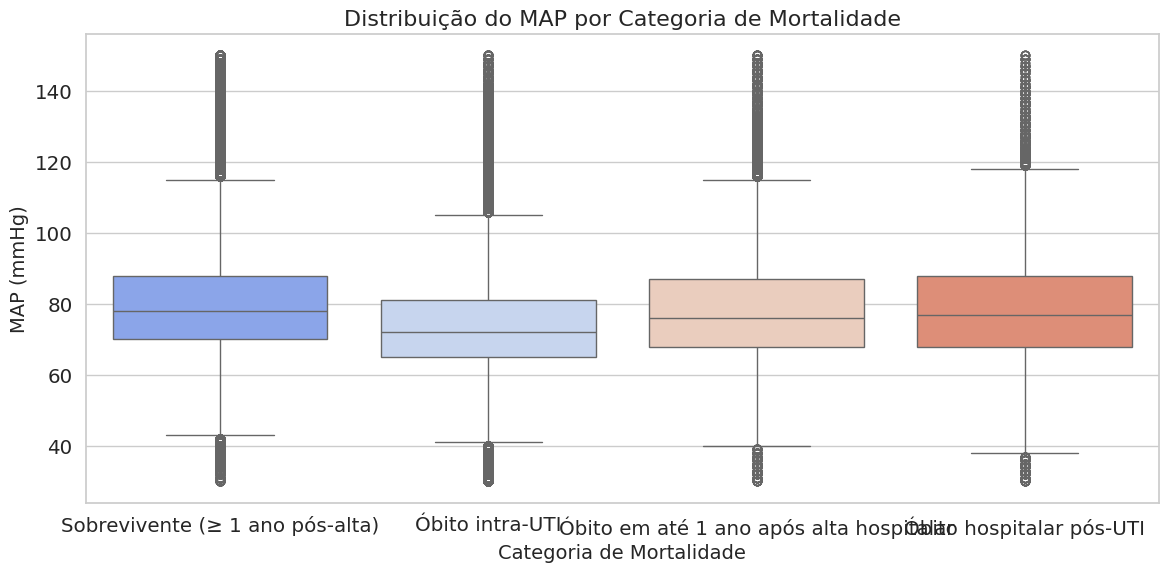

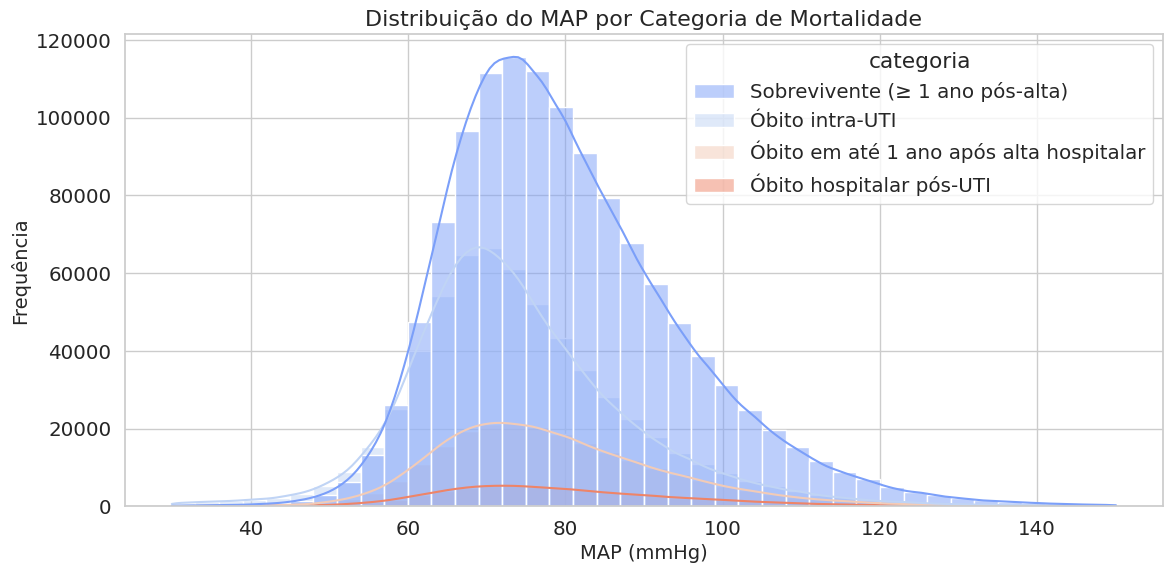

In [8]:


# Consulta SQL para coletar valores de MAP e mortalidade
query_map_mortalidade = """
WITH map_values AS (
    SELECT
        ce.stay_id,
        ce.valuenum AS map,
        pm.categoria
    FROM mimiciv_icu.chartevents ce
    JOIN pacientes_mortos pm ON ce.stay_id = pm.stay_id
    WHERE ce.itemid = 220052  -- MAP  
      AND ce.valuenum IS NOT NULL
      AND ce.valuenum BETWEEN 30 AND 150  -- MAP plausível
)
SELECT
    categoria,
    map
FROM map_values;
"""
#220045 blood pressure
# Carregar os dados em um DataFrame
df_map = pd.read_sql(query_map_mortalidade, conn)


# Exibir estatísticas descritivas
print("\n📊 Estatísticas descritivas do MAP por categoria de mortalidade:")
print(df_map.groupby("categoria")["map"].describe())

# Boxplot para comparar MAP por categoria de mortalidade
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_map, x="categoria", y="map", palette="coolwarm")
plt.title("Distribuição do MAP por Categoria de Mortalidade", fontsize=16)
plt.xlabel("Categoria de Mortalidade", fontsize=14)
plt.ylabel("MAP (mmHg)", fontsize=14)
plt.tight_layout()
plt.show()

# Histograma para visualizar a distribuição do MAP por mortalidade
plt.figure(figsize=(12, 6))
sns.histplot(data=df_map, x="map", hue="categoria", bins=40, kde=True, palette="coolwarm", alpha=0.5)
plt.title("Distribuição do MAP por Categoria de Mortalidade", fontsize=16)
plt.xlabel("MAP (mmHg)", fontsize=14)
plt.ylabel("Frequência", fontsize=14)
plt.tight_layout()
plt.show()




/tmp/ipykernel_25474/406808479.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_map = pd.read_sql(query_map_mortalidade, conn)



📊 Estatísticas descritivas do MAP por categoria de mortalidade:
                                             count       mean        std  \
categoria                                                                  
Sobrevivente (≥ 1 ano pós-alta)          1229679.0  79.990590  14.751860   
Óbito em até 1 ano após alta hospitalar   230595.0  78.474815  14.597553   
Óbito hospitalar pós-UTI                   60358.0  79.200868  15.595666   
Óbito intra-UTI                           610045.0  74.188596  14.181316   

                                          min   25%   50%   75%    max  
categoria                                                               
Sobrevivente (≥ 1 ano pós-alta)          30.0  70.0  78.0  88.0  150.0  
Óbito em até 1 ano após alta hospitalar  30.0  68.0  76.0  87.0  150.0  
Óbito hospitalar pós-UTI                 30.0  68.0  77.0  88.0  150.0  
Óbito intra-UTI                          30.0  65.0  72.0  81.0  150.0  


/tmp/ipykernel_25474/406808479.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_extremos, x="categoria", y="map", palette="coolwarm")


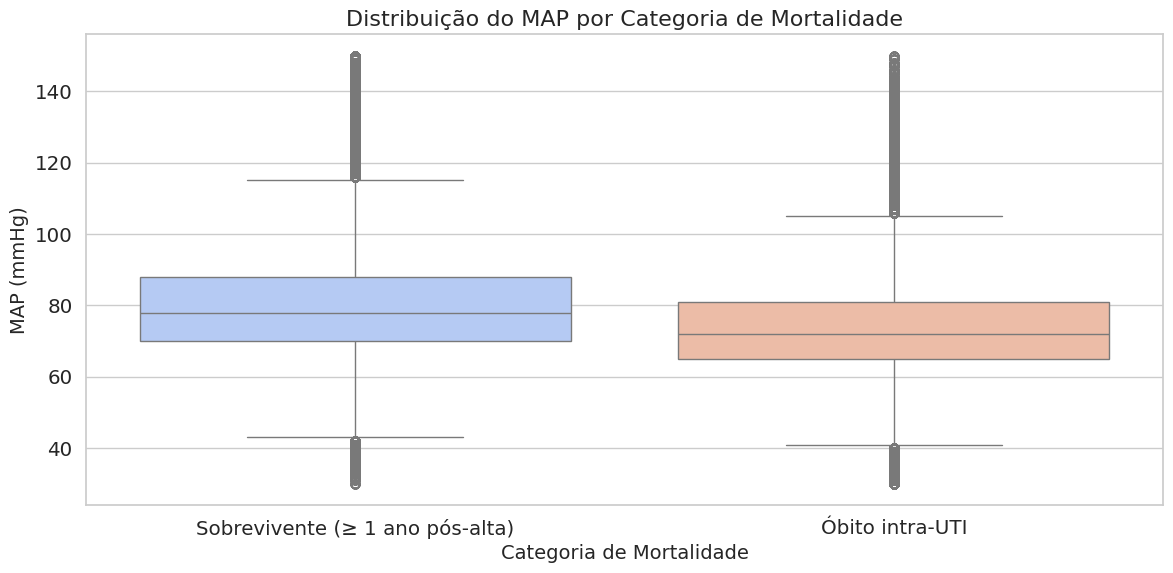

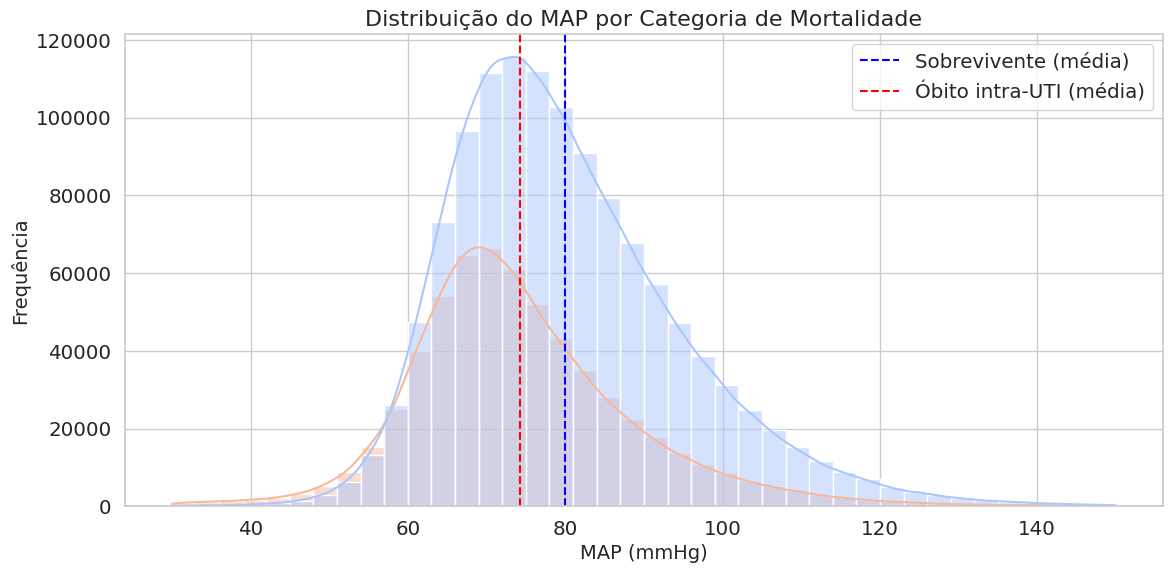

In [9]:
# Consulta SQL para coletar valores de MAP e mortalidade
query_map_mortalidade = """
WITH map_values AS (
    SELECT
        ce.stay_id,
        ce.valuenum AS map,
        pm.categoria
    FROM mimiciv_icu.chartevents ce
    JOIN pacientes_mortos pm ON ce.stay_id = pm.stay_id
    WHERE ce.itemid = 220052  -- MAP  
      AND ce.valuenum IS NOT NULL
      AND ce.valuenum BETWEEN 30 AND 150  -- MAP plausível
)
SELECT
    categoria,
    map
FROM map_values;
"""
#220045 blood pressure
# Carregar os dados em um DataFrame
df_map = pd.read_sql(query_map_mortalidade, conn)

df_extremos = df_map[df_map['categoria'].isin([
    "Sobrevivente (≥ 1 ano pós-alta)",
    "Óbito intra-UTI"
])]



# Exibir estatísticas descritivas
print("\n📊 Estatísticas descritivas do MAP por categoria de mortalidade:")
print(df_map.groupby("categoria")["map"].describe())

# Boxplot para comparar MAP por categoria de mortalidade
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_extremos, x="categoria", y="map", palette="coolwarm")
plt.title("Distribuição do MAP por Categoria de Mortalidade", fontsize=16)
plt.xlabel("Categoria de Mortalidade", fontsize=14)
plt.ylabel("MAP (mmHg)", fontsize=14)
plt.tight_layout()
plt.show()

# Histograma para visualizar a distribuição do MAP por mortalidade
plt.figure(figsize=(12, 6))
sns.histplot(data=df_extremos, x="map", hue="categoria", bins=40, kde=True, palette="coolwarm", alpha=0.5)

#moda dos sobreviventes e dos óbitos intra-UTI
#plt.axvline(df_extremos[df_extremos['categoria'] == 'Sobrevivente (≥ 1 ano pós-alta)']['map'].mode()[0], color='blue', linestyle='--', label='Sobrevivente (moda)')
#plt.axvline(df_extremos[df_extremos['categoria'] == 'Óbito intra-UTI']['map'].mode()[0], color='red', linestyle='--', label='Óbito intra-UTI (moda)')

#média dos sobreviventes e dos óbitos intra-UTI	
plt.axvline(df_extremos[df_extremos['categoria'] == 'Sobrevivente (≥ 1 ano pós-alta)']['map'].mean(), color='blue', linestyle='--', label='Sobrevivente (média)')
plt.axvline(df_extremos[df_extremos['categoria'] == 'Óbito intra-UTI']['map'].mean(), color='red', linestyle='--', label='Óbito intra-UTI (média)')
plt.legend()

plt.title("Distribuição do MAP por Categoria de Mortalidade", fontsize=16)
plt.xlabel("MAP (mmHg)", fontsize=14)
plt.ylabel("Frequência", fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_25474/3572508551.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_map = pd.read_sql(query_map_mortalidade, conn)


📌 Mann-Whitney U Test: estatística=463315908206.00, p-valor=0.00000

📊 Estatísticas descritivas do MAP por categoria de mortalidade:
                                             count       mean        std  \
categoria                                                                  
Sobrevivente (≥ 1 ano pós-alta)          1229679.0  79.990590  14.751860   
Óbito em até 1 ano após alta hospitalar   230595.0  78.474815  14.597553   
Óbito hospitalar pós-UTI                   60358.0  79.200868  15.595666   
Óbito intra-UTI                           610045.0  74.188596  14.181316   

                                          min   25%   50%   75%    max  
categoria                                                               
Sobrevivente (≥ 1 ano pós-alta)          30.0  70.0  78.0  88.0  150.0  
Óbito em até 1 ano após alta hospitalar  30.0  68.0  76.0  87.0  150.0  
Óbito hospitalar pós-UTI                 30.0  68.0  77.0  88.0  150.0  
Óbito intra-UTI                          30.0

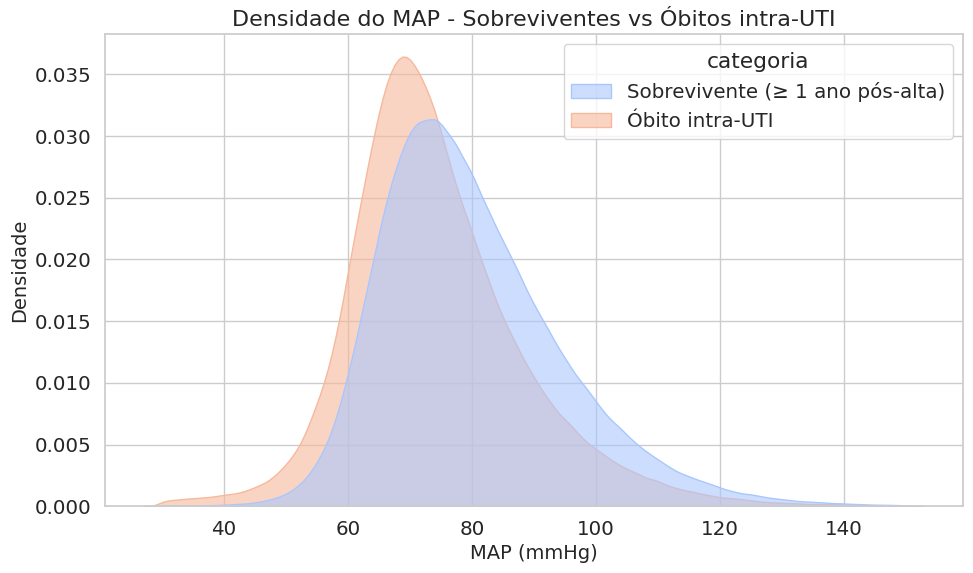

In [10]:
#%pip install scipy

from scipy.stats import mannwhitneyu

# Consulta SQL para coletar valores de MAP e mortalidade
query_map_mortalidade = """
WITH map_values AS (
    SELECT
        ce.stay_id,
        ce.valuenum AS map,
        pm.categoria
    FROM mimiciv_icu.chartevents ce
    JOIN pacientes_mortos pm ON ce.stay_id = pm.stay_id
    WHERE ce.itemid = 220052  -- MAP  
      AND ce.valuenum IS NOT NULL
      AND ce.valuenum BETWEEN 30 AND 150  -- MAP plausível
)
SELECT
    categoria,
    map
FROM map_values;
"""
#220045 blood pressure
# Carregar os dados em um DataFrame
df_map = pd.read_sql(query_map_mortalidade, conn)

df_extremos = df_map[df_map['categoria'].isin([
    "Sobrevivente (≥ 1 ano pós-alta)",
    "Óbito intra-UTI"
])]



grupo_vivo = df_extremos[df_extremos['categoria'] == "Sobrevivente (≥ 1 ano pós-alta)"]['map']
grupo_morto = df_extremos[df_extremos['categoria'] == "Óbito intra-UTI"]['map']

stat, p = mannwhitneyu(grupo_vivo, grupo_morto, alternative='two-sided')
print(f"📌 Mann-Whitney U Test: estatística={stat:.2f}, p-valor={p:.5f}")


# Exibir estatísticas descritivas
print("\n📊 Estatísticas descritivas do MAP por categoria de mortalidade:")
print(df_map.groupby("categoria")["map"].describe())

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_extremos, x="map", hue="categoria", fill=True, common_norm=False, palette="coolwarm", alpha=0.6)
plt.title("Densidade do MAP - Sobreviventes vs Óbitos intra-UTI", fontsize=16)
plt.xlabel("MAP (mmHg)", fontsize=14)
plt.ylabel("Densidade", fontsize=14)
plt.tight_layout()
plt.show()




/tmp/ipykernel_25474/501575516.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_map = pd.read_sql(query_map_mortalidade, conn)



📊 Estatísticas descritivas do MAP médio por categoria de mortalidade:
                                   count       mean        std   min  \
categoria                                                              
Sobrevivente (≥ 1 ano pós-alta)  19382.0  79.537225   9.683531  31.0   
Óbito intra-UTI                   4446.0  72.977290  10.835306  30.0   

                                       25%        50%        75%    max  
categoria                                                                
Sobrevivente (≥ 1 ano pós-alta)  72.881645  77.783167  84.604545  148.0  
Óbito intra-UTI                  66.666667  72.426786  78.625000  134.0  


/tmp/ipykernel_25474/501575516.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_extremos, x="categoria", y="map_avg", palette="coolwarm")


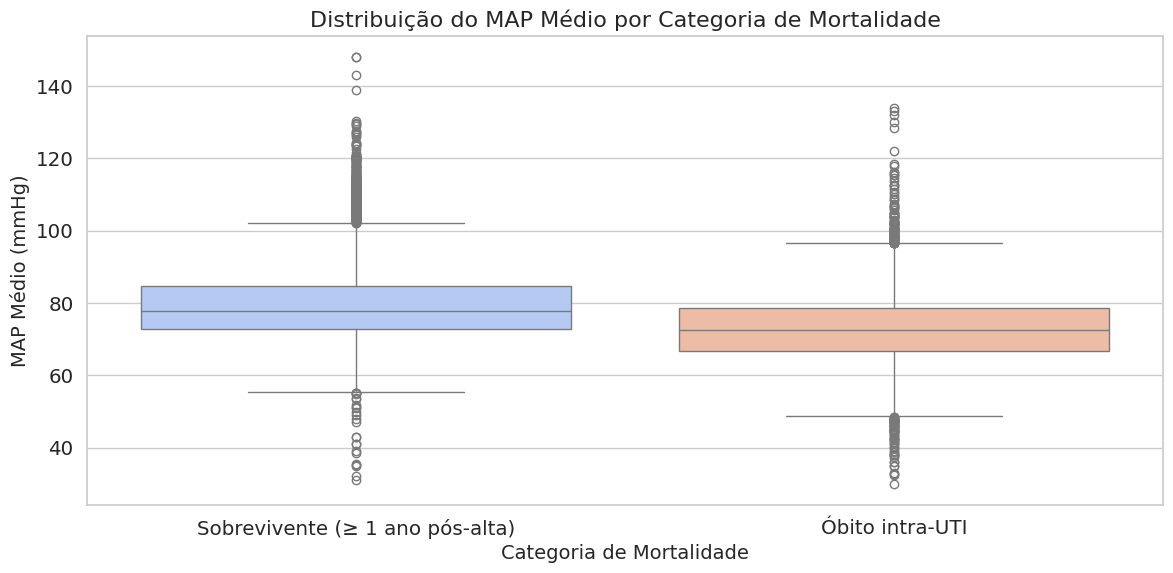

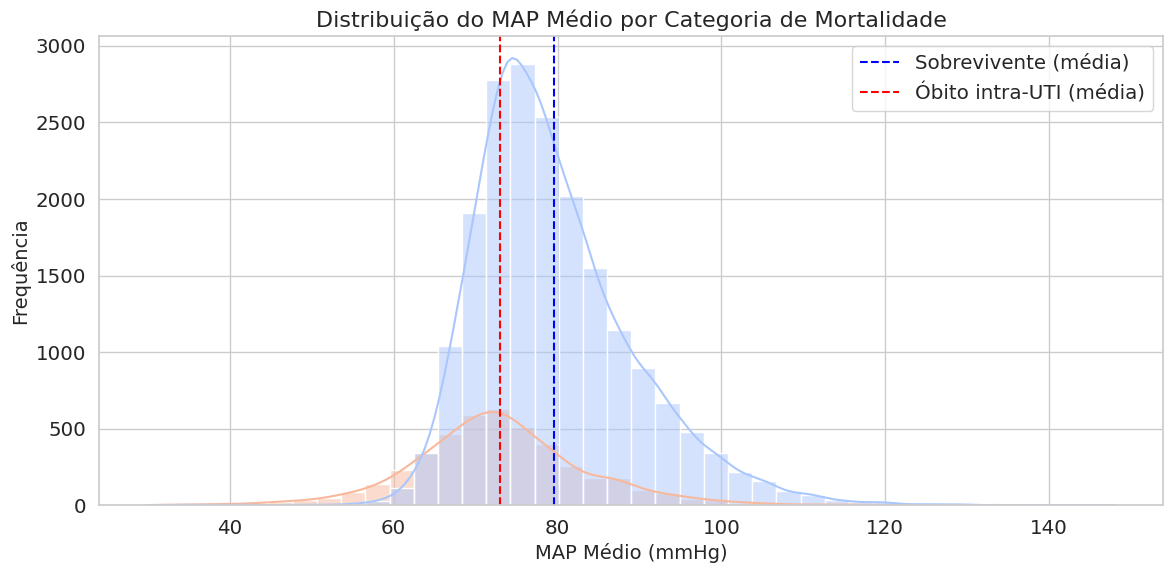

In [13]:
# Consulta SQL para coletar valores de MAP e mortalidade
query_map_mortalidade = """
WITH map_values AS (
    SELECT
        ce.stay_id,
        AVG(ce.valuenum) AS map_avg,
        MIN(ce.valuenum) AS map_min,
        MAX(ce.valuenum) AS map_max,
        pm.categoria
    FROM mimiciv_icu.chartevents ce
    JOIN pacientes_mortos pm ON ce.stay_id = pm.stay_id
    WHERE ce.itemid = 220052  
      AND ce.valuenum BETWEEN 30 AND 150
    GROUP BY ce.stay_id, pm.categoria
)
SELECT * FROM map_values;

"""
#220045 blood pressure
# Carregar os dados em um DataFrame
df_map = pd.read_sql(query_map_mortalidade, conn)

df_extremos = df_map[df_map['categoria'].isin([
    "Sobrevivente (≥ 1 ano pós-alta)",
    "Óbito intra-UTI"
])]



# Exibir estatísticas descritivas
print("\n📊 Estatísticas descritivas do MAP médio por categoria de mortalidade:")
print(df_extremos.groupby("categoria")["map_avg"].describe())

# Boxplot para comparar MAP médio por categoria de mortalidade
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_extremos, x="categoria", y="map_avg", palette="coolwarm")
plt.title("Distribuição do MAP Médio por Categoria de Mortalidade", fontsize=16)
plt.xlabel("Categoria de Mortalidade", fontsize=14)
plt.ylabel("MAP Médio (mmHg)", fontsize=14)
plt.tight_layout()
plt.show()

# Histograma para visualizar a distribuição do MAP médio por mortalidade
plt.figure(figsize=(12, 6))
sns.histplot(data=df_extremos, x="map_avg", hue="categoria", bins=40, kde=True, palette="coolwarm", alpha=0.5)

#média dos sobreviventes e dos óbitos intra-UTI	
plt.axvline(df_extremos[df_extremos['categoria'] == 'Sobrevivente (≥ 1 ano pós-alta)']['map_avg'].mean(), color='blue', linestyle='--', label='Sobrevivente (média)')
plt.axvline(df_extremos[df_extremos['categoria'] == 'Óbito intra-UTI']['map_avg'].mean(), color='red', linestyle='--', label='Óbito intra-UTI (média)')
plt.legend()

plt.title("Distribuição do MAP Médio por Categoria de Mortalidade", fontsize=16)
plt.xlabel("MAP Médio (mmHg)", fontsize=14)
plt.ylabel("Frequência", fontsize=14)
plt.tight_layout()
plt.show()